### Customer Churn Prediction - Telco Dataset

Decision Tree vs logistic Regression

**Goal**: Predict which customers are about to churn (cancel their service), understand why they churn and compare two classic classification models - a **Decision tree** and a **Logistic Regression**

**Dataset**: Telco customer churn data - 7043 customers, 21 columns covering demographics, the service they have subscribed to, account/billing info, and whether they churned.

### Import libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Random_state = 42 # fixed seeds so results are reproducible

**Interpretation**:

**from sklearn.model_selection import train_test_split**: Imports the function used to split your dataset into trainig sets(for model learning) and testing sets(for evaluation).

**from sklearn.preprocessing import StandardScaler**: Imports a feature scalar that standardize data to have a mean of 0 and variance of 1, placing features on equal footing.

**from sklearn.linear_model import LogisticRegression**: Imports Logistic Regression, a foundational classification algorithm used to predict binary or categorical outcomes.

**from sklearn.tree import DecisionTreeClassifier, plot_tree**: Import the decision tree classifier along with plot_tree,a utility used to draw and inspect the generated tree rules visually.

**from sklearn.metrics import **: Opens a grouped import statement to bring in multiple performance evaluation tools from Scikit-Learn's metrics module.

**accuracy_score, precision_score, recall_score, f1_score,**: Imports key classification evaluation metrics to measure overall correctness, false alarms, missed targets, and their balance.

**roc_auc_score, roc_curve, confusion_matrix, classification_report**: Imports diagnostic tools to measure trade-offs between true/false positive rates and visualize prediction outcomes in matrix/summary forms.

**%matplotlib inline**: A Jupyter Notebook magic command that renders generated plots directly inside the notebook output cells instead of separate windows.

**sns.set_style('whitegrid')**: Applies a visual theme to Seaborn plots featuring a clean white background with light horizontal and vertical gridlines.

**plt.rcParams['figure.dpi'] = 100**: Sets the default resolution of all generated Matplotlib figures to 100 dots-per-inch, making output images sharper.

### Load and Inspect data

In [4]:
df = pd.read_csv('telco_churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info() # quick summary of datafra,es structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**TotalCharges** is stored as text(object), not a number - that needs fixing before we can model with it.

**customerID** is just a unique identifier with no predictive value -  we'll drop it .

**The target column Churn is Yes/No - we'll convert it to 1/0.

In [9]:
print("Null Values per column :")
print(df.isnull().sum().sum(),"Total nulls found this way")

Null Values per column :
0 Total nulls found this way


In [10]:
# Total charges have some blank hidden strings hidden inside it
blank_mask = df['TotalCharges'].str.strip() ==""
print(f"\nRows with a blank TotalCharges:{blank_mask.sum()}")
df.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


Rows with a blank TotalCharges:11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**All 11 blank rows belong to customers with tenure=0 - brand-new customers who haven't been billed yet. It's safe to fill these with 0 rather than drop the rows.

In [12]:
df_clean = df.copy()

# Fix TotalCharges: coerce to numeric, fill the 11 new-customer blanks with 0
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

# customerID carries no signal - drop it
df_clean = df_clean.drop(columns=["customerID"])

# Encode the target: Yes -> 1 (churned), No -> 0 (stayed)
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

df_clean.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

### Exploratory data analysis

Which features look related to churn?

In [13]:
df_eda = df_clean.copy()
df_eda['Churn Label']=df_eda['Churn'].map({0:"Stayed", 1:'Churned'})

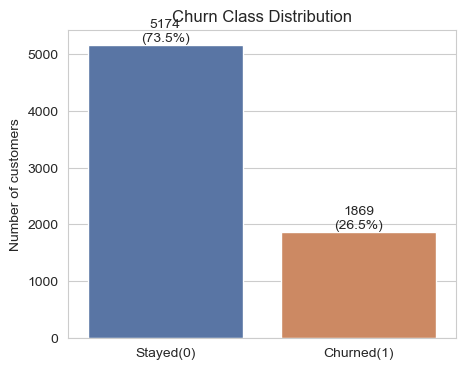

Overall churn rate: 26.5%


In [15]:
churn_counts = df_clean['Churn'].value_counts().sort_index()
churn_rate = df_clean['Churn'].mean()

fig, ax = plt.subplots(figsize=(5,4))
sns.barplot(
    x=['Stayed(0)','Churned(1)'],
    y = churn_counts.values,
    palette = ["#4C72B0", "#DD8452"],
    ax = ax,
    hue = ['Stayed(0)','Churned(1)'],
    legend = False
)
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 60, f"{v}\n({v/len(df_clean)*100:.1f}%)", ha="center")
ax.set_title("Churn Class Distribution")
ax.set_ylabel("Number of customers")
plt.show()

print(f"Overall churn rate: {churn_rate*100:.1f}%")

**CLass imbalance flag**: Churners make up only 26 or 27% of the data -  roughly a 2.8:1 imbalance in favpur of stayed customers. It's not an extreme imbalance, but its not enough that a model can get 73% accuracy just by predicting no chirn or everyone, which would be useless in practice

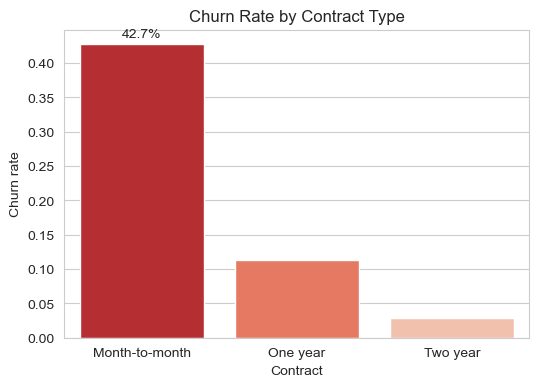

In [19]:
fig, ax = plt.subplots(figsize=(6,4))
contract_churn = df_clean.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values,
    palette = 'Reds_r',
    ax = ax,
    hue = contract_churn.index,
    legend = False
)
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Churn rate")

for i, v in enumerate(contract_churn.values):
    ax.text(i, v + 0.01, f"{v*100:.1f}%", ha="center")
    plt.show()

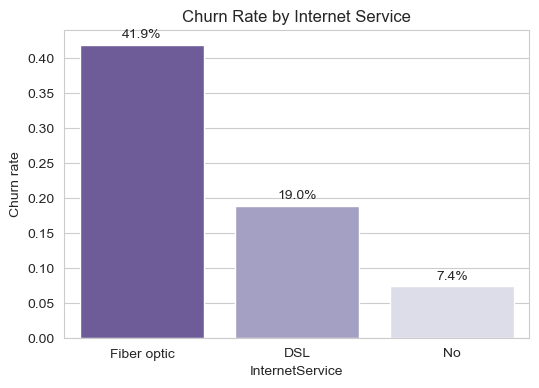

In [22]:
fig, ax = plt.subplots(figsize=(6,4))
net_churn = df_clean.groupby('InternetService')['Churn'].mean().sort_values(ascending=False)
sns.barplot(
    x=net_churn.index,
    y=net_churn.values,
    palette = 'Purples_r',
    ax = ax,
    hue = net_churn.index,
    legend = False
)
ax.set_title("Churn Rate by Internet Service")
ax.set_ylabel("Churn rate")
for i, v in enumerate(net_churn.values):
    ax.text(i, v + 0.01, f"{v*100:.1f}%", ha="center")
plt.show()

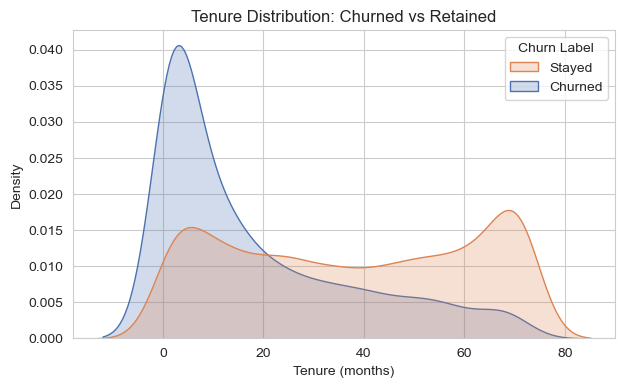

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df_eda, x="tenure", hue="Churn Label", fill=True,
            common_norm=False, palette=["#DD8452", "#4C72B0"], ax=ax)
ax.set_title("Tenure Distribution: Churned vs Retained")
ax.set_xlabel("Tenure (months)")
plt.show()

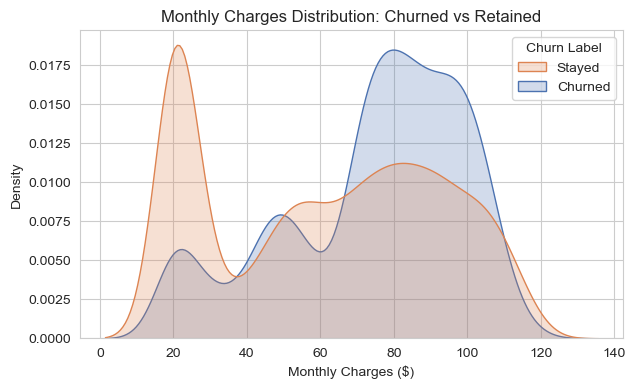

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df_eda, x="MonthlyCharges", hue="Churn Label", fill=True,
            common_norm=False, palette=["#DD8452", "#4C72B0"], ax=ax)
ax.set_title("Monthly Charges Distribution: Churned vs Retained")
ax.set_xlabel("Monthly Charges ($)")
plt.show()

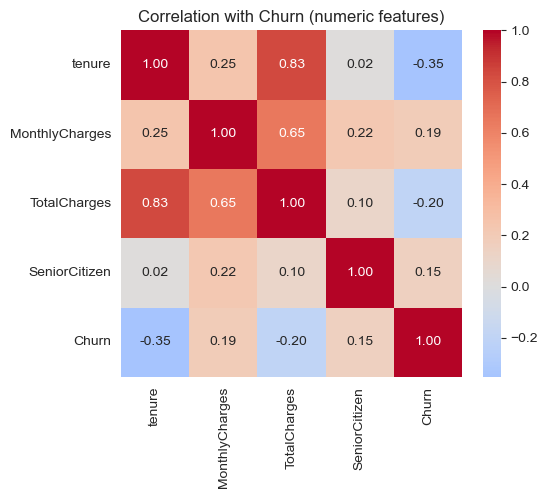

In [25]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn"]
corr = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax)
ax.set_title("Correlation with Churn (numeric features)")
plt.show()


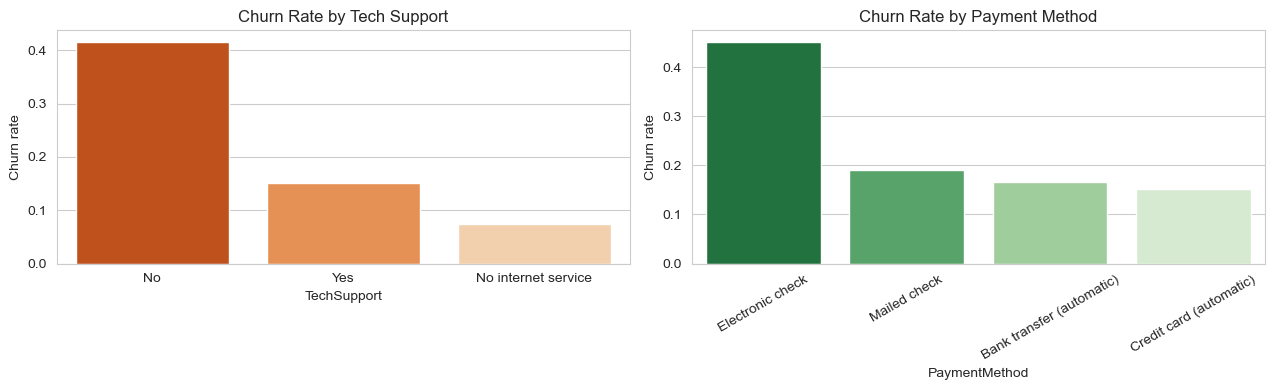

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Subplot 1: Tech Support
tech_churn = df_clean.groupby("TechSupport")["Churn"].mean().sort_values(ascending=False)
sns.barplot(
    x=tech_churn.index, 
    y=tech_churn.values, 
    hue=tech_churn.index,  # Fixes palette deprecation warning
    palette="Oranges_r", 
    ax=axes[0], 
    legend=False
)
axes[0].set_title("Churn Rate by Tech Support")
axes[0].set_ylabel("Churn rate")

# Subplot 2: Payment Method
pay_churn = df_clean.groupby("PaymentMethod")["Churn"].mean().sort_values(ascending=False)
sns.barplot(
    x=pay_churn.index, 
    y=pay_churn.values, 
    hue=pay_churn.index,  # Changed from string 'pay_churn' to pay_churn.index
    palette="Greens_r", 
    ax=axes[1], 
    legend=False
)
axes[1].set_title("Churn Rate by Payment Method")
axes[1].set_ylabel("Churn rate")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

**EDA takeaways**

**Contract type is the strongest pattern in the data**. Month-to-month customers churn at ~43%, vs ~11% for one-year contracts and just ~3% for two-year contracts.

**Fiber optic internet customers churn far more (~42%)** than DSL customers (~19%) or customers with no internet service (~7%) — worth investigating as a service-quality question.

**Tenure is negatively correlated with churn (-0.35)** — newer customers are much more likely to leave; risk drops off the longer someone stays.

**Customers without Tech Support churn much more (~42%)** than those with it (~15%), and Monthly/Total Charges show a mild positive/negative correlation with churn (higher bills, lower loyalty).

**Electronic check payers churn the most (~45%)**, vs ~15% for automatic credit-card payments — friction in the payment method may correlate with disengagement.

Confirmed above: the dataset is moderately imbalanced (~26.5% churn), which we account for next.

**3. Preparing the Data for Modeling**
Handling categorical variables: Most columns here (Contract, InternetService, PaymentMethod, Partner, etc.) are text categories, and models need numbers. We use one-hot encoding (pd.get_dummies), which turns each category into its own 0/1 column, dropping one category per feature as a baseline to avoid redundancy.

In [39]:
cat_cols = df_clean.select_dtypes(include="object").columns.tolist()
print(f"Categorical columns to encode ({len(cat_cols)}):")
print(cat_cols)

df_model = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)
print(f"\nShape after encoding: {df_model.shape}")
df_model.head()

Categorical columns to encode (15):
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape after encoding: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [41]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nChurn rate in train:", round(y_train.mean(), 3))
print("Churn rate in test: ", round(y_test.mean(), 3))

Train shape: (5634, 30)  Test shape: (1409, 30)

Churn rate in train: 0.265
Churn rate in test:  0.265


**Handling class imbalance:** we flagged in Section 2 that only ~26.5% of customers churn. We used stratify=y above so the train/test split keeps that same ratio in both sets. For the models themselves, we set class_weight="balanced" on both the Decision Tree and Logistic Regression — this makes the model pay proportionally more attention to the minority (churned) class during training, instead of just learning to predict "no churn" for everyone.

This is a lightweight fix, not a complete one. We're not applying resampling techniques like SMOTE (synthetic oversampling) or random undersampling here — that's a reasonable next step (noted again in Section 8) but out of scope for this first pass. We also deliberately look at precision, recall, F1, and ROC-AUC below rather than leaning on accuracy, since accuracy is misleading on imbalanced data.

In [44]:
# Logistic Regression is distance-based, so it benefits from scaled features.
# The Decision Tree does NOT need scaling (it splits on thresholds, not distances),
# so we keep an unscaled version of X for the tree.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**4. Train the Models**

In [48]:
# Decision Tree — max_depth=5 keeps it interpretable (a deeper tree overfits and gets hard to read)
dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]
print("Decision Tree trained.")

Decision Tree trained.


In [50]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]
print("Logistic Regression trained.")

Logistic Regression trained.


**5. Compare Model Performance**

In [51]:
def get_metrics(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
    }

results = pd.DataFrame([
    get_metrics("Decision Tree", y_test, dt_pred, dt_prob),
    get_metrics("Logistic Regression", y_test, lr_pred, lr_prob),
]).set_index("Model").round(3)

results

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Decision Tree,0.735,0.500,0.807,0.618,0.831
Logistic Regression,0.740,0.507,0.786,0.616,0.841


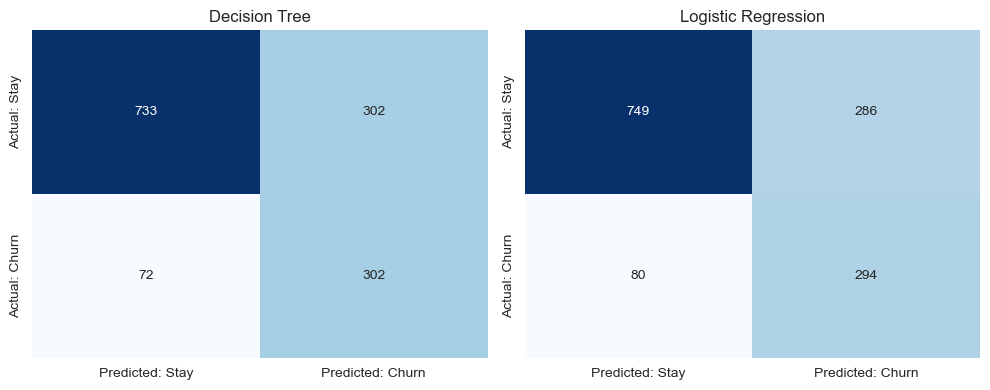

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, preds) in zip(axes, [("Decision Tree", dt_pred), ("Logistic Regression", lr_pred)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Predicted: Stay", "Predicted: Churn"],
                yticklabels=["Actual: Stay", "Actual: Churn"])
    ax.set_title(name)

plt.tight_layout()
plt.show()

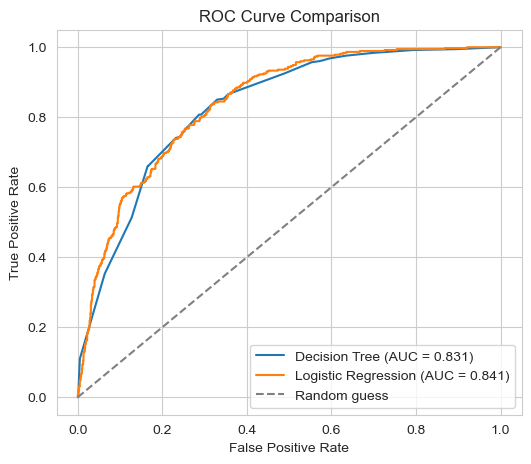

In [53]:
fig, ax = plt.subplots(figsize=(6, 5))

for name, prob in [("Decision Tree", dt_prob), ("Logistic Regression", lr_prob)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.show()

Reading the comparison:

Both models land in a similar range: ~73-74% accuracy, but that number matters less here than recall — the fraction of actual churners the model successfully catches — because a missed churner is a lost customer we never got the chance to retain.
Both models catch roughly 8 out of 10 churners (recall ≈ 0.79-0.81), which is exactly what we'd hope for from class_weight="balanced" — it trades some precision for much better recall than an unweighted model would give us.
Logistic Regression edges out the Decision Tree on ROC-AUC, meaning it ranks customers by churn risk slightly more reliably overall — useful if the business wants a prioritized watch-list rather than a hard yes/no.
The Decision Tree is easier to explain — Section 6 shows exactly why it flags a customer as high-risk, which matters a lot when the audience is non-technical.
In practice, a reasonable recommendation is: use the Decision Tree for stakeholder-facing explanations, and consider Logistic Regression (or an ensemble of both) for the actual ranking/scoring used to prioritize outreach.

**6. What's Driving Churn? (Feature Importance)**

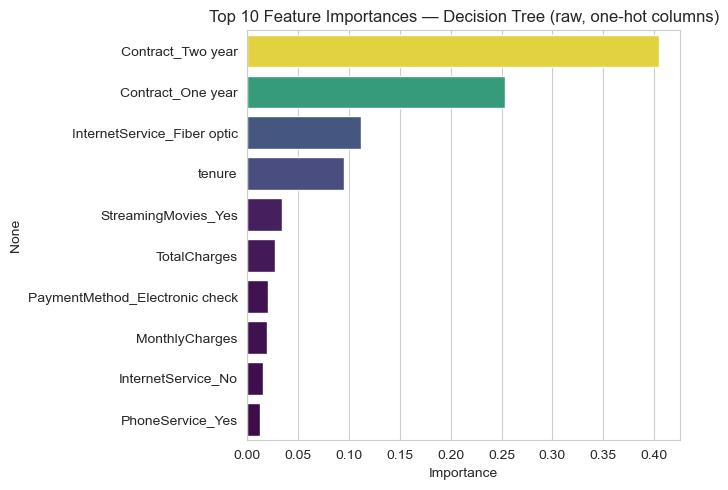

In [54]:
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=top10.values, y=top10.index, palette="viridis", ax=ax, hue=top10.values, legend=False)
ax.set_title("Top 10 Feature Importances — Decision Tree (raw, one-hot columns)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

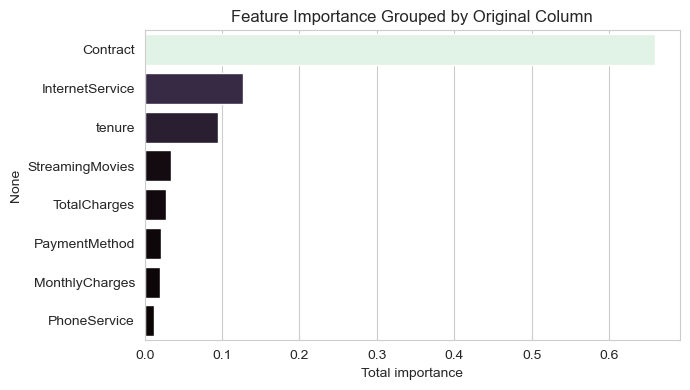

Top 3 features driving churn (Decision Tree, .feature_importances_):
  1. Contract  (importance = 0.659)
  2. InternetService  (importance = 0.127)
  3. tenure  (importance = 0.095)


In [56]:
# One categorical feature (e.g. Contract) becomes several one-hot columns.
# To answer "top 3 FEATURES" in business terms, we re-group importances back
# to their original column names.
def base_feature(col):
    for c in cat_cols:
        if col.startswith(c + "_"):
            return c
    return col

grouped_importance = importances.groupby(base_feature).sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=grouped_importance.head(8).values, y=grouped_importance.head(8).index,
            palette="mako", ax=ax, hue=grouped_importance.head(8).values, legend=False)
ax.set_title("Feature Importance Grouped by Original Column")
ax.set_xlabel("Total importance")
plt.tight_layout()
plt.show()

print("Top 3 features driving churn (Decision Tree, .feature_importances_):")
for i, (feat, score) in enumerate(grouped_importance.head(3).items(), start=1):
    print(f"  {i}. {feat}  (importance = {score:.3f})")

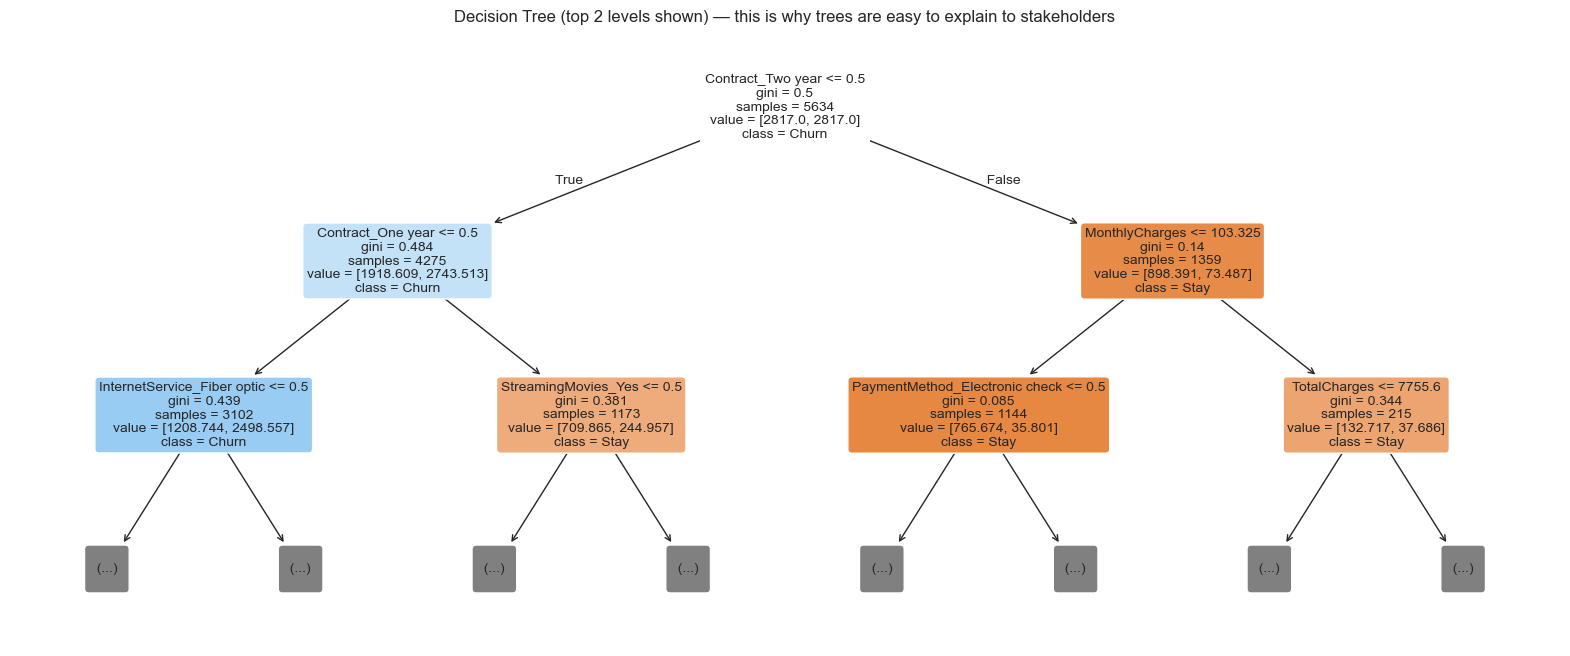

In [57]:
# A shallow view of the actual fitted tree - this is the kind of visual you can put
# directly in front of a manager: "if contract = two-year, churn risk is low", etc.
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_model,
    max_depth=2,           # only display the first 2 levels for readability
    feature_names=X.columns,
    class_names=["Stay", "Churn"],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title("Decision Tree (top 2 levels shown) — this is why trees are easy to explain to stakeholders")
plt.show()

**7. Business Summary (for a non-technical manager)**
About 1 in 4 customers (26.5%) in this dataset churned, and the pattern behind it is quite predictable — our model correctly flags roughly 8 out of 10 customers who are about to leave, before they actually cancel. The single biggest driver is contract type: month-to-month customers churn at 43%, compared with 11% on one-year contracts and under 3% on two-year contracts, so moving more customers onto longer commitments — even with a modest incentive — is likely our highest-leverage retention lever. Fiber internet customers churn nearly 3x more often than DSL customers (42% vs 19%), and customers without Tech Support churn far more than those with it (42% vs 15%), which together point to a service-quality or support-experience gap worth investigating on the fiber product. Newer customers are also our highest-risk group — churn risk drops steadily the longer someone stays — so the first few months of the relationship deserve proactive attention (onboarding check-ins, an early-tenure discount, or a support outreach). Bottom line: a retention campaign targeted at month-to-month, fiber-internet customers in their first few months without Tech Support would concentrate our efforts on the segment carrying the most churn risk.

**8. Limitations & Next Steps**
Class imbalance was only partially addressed. We used class_weight="balanced", but we did not apply resampling (e.g. SMOTE, random over/undersampling) — that's a natural next experiment and could push recall higher still.
Both models are a first pass, not tuned. A grid/random search over max_depth, min_samples_leaf (tree) and C, penalty (logistic regression) would likely improve results.
Stronger models (Random Forest, Gradient Boosting / XGBoost) would likely outperform a single Decision Tree on raw metrics, at the cost of some interpretability.
The decision threshold (0.5) wasn't tuned. Since missing a churner is costlier than a false alarm, lowering the threshold to boost recall further (at some precision cost) may better match business goals.
More features would help: customer service call logs, complaint history, or usage trends over time aren't in this dataset but are commonly strong churn predictors in practice.